# Lab | Introduction to LoRA Tuning using PEFT from Hugging Face
<!-- ### Fine-tune a Foundational Model effortlessly -->

**Note:** This is more or less the same notebook you saw in the previous lesson, but that is ok. This is an LLM fine-tuning lab. In class we used a set of datasets and models, and in the labs you are required to change the LLMs models and the datasets including the pre-processing pipelines.


# LoRA Tuning

In this notebook you are being introduced to how to apply LoRA Tuning with the PEFT library to a pre-trained model.

For a complete list of Models compatible with PEFT refer to their [documentation](https://huggingface.co/docs/peft/main/en/index#supported-methods).

A short sample of models families available to be trained with PEFT are: Bloom, Llama, GPT-J, GPT-2, BERT... and more. Hugging Face is working hard to bring more Models to the Library.

## Brief introduction to LoRA Tuning.
LoRA is a re-parameterization technique. Its operation is simple, complex, and brilliant at the same time. It involves reducing the size of the matrices to be trained by dividing them in such a way that when multiplied, they yield the original matrix.

The weights that are modified are those of the reduced matrices, not the original matrix. It's better visualized in an image.

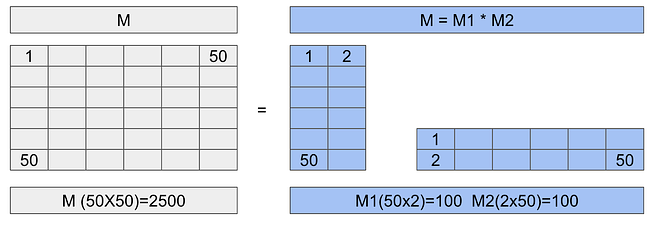

We have an original matrix of 50x50, which means we would have to modify about 2500 parameters. However, as we know, if we multiply two matrices of (2x50) and (50x2), we obtain a 50x50 matrix. Yet, these two matrices are formed by only 100 parameters each. In other words, for the reduced matrices, we need to modify a total of 200 parameters compared to the 2500 of the original matrix. This represents a 92% reduction, and the larger the original matrix, the greater the percentage of savings.

In Language Models like GPT-3 or any of the current ones with LoRA, it's possible that we only need to train about 0.02% of the original parameters. This varies for each model. The best part is that the obtained result is very similar to that of full fine-tuning, in some cases, it can even be better.

# Load the PEFT and Datasets Libraries.

The PEFT library contains the Hugging Face implementation of differente fine-tuning techniques, like LoRA Tuning.

Using the Datasets library we have acces to a huge amount of Datasets.

In [13]:
# Use a clean, compatible dependency set for Colab.
# This avoids the PEFT/TorchAO version mismatch that breaks LoRA setup.
!pip install -q --upgrade --force-reinstall \
  "peft>=0.15.0" \
  "torchao>=0.16.0" \
  "transformers>=4.50.0" \
  "datasets==2.16.1" \
  "accelerate>=0.33.0" \
  "ipywidgets==7.7.5"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.6/111.6 kB 9.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.4/46.4 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 35.7 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.2/123.2 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 639.0/639.0 kB 46.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 13.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.2/86.2 kB 574.9 kB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 40.5 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 56.7 MB/s eta 0:00:0000:010:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.6/268.6 kB 18.8 MB/s eta 0:00:00
 

From the transformers library we import the necesary classes to import the model and the tokenizer.

Then we can load the Tokenizer and the model.

Bloom is one of the smallest and smarter model available to be trained with PEFT Library using Prompt Tuning. You can use either of the models in the Bloom Family, I encorage you to use at least two of them and see the differences.

I'm using the smallest one just to spend less time trainig, and avoid memory problems in Colab.

In [14]:
import gc
import os
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

# GPU memory can get split into leftover pieces. This helps PyTorch reuse that space.
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
# Clear GPU memory that is no longer needed before we load the model.
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

model_name = "bigscience/bloom-560m"

tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.padding_side = "right"   # right-padding for TRAINING (we switch to left later, only for generation)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

foundation_model = AutoModelForCausalLM.from_pretrained(
    model_name,
    device_map="auto",
    attn_implementation="eager"   # avoids a known SDPA/padding numerical bug
)
foundation_model.config.pad_token_id = tokenizer.pad_token_id

Loading weights:   0%|          | 0/293 [00:00<?, ?it/s]

## Inference with the pre-trained model.
I'm going to do a test with the pre-trained model without fine-tuning, to see if something changes after the fine-tuning.

In [15]:
def get_outputs(model, inputs, max_new_tokens=100):
    outputs = model.generate(
        input_ids=inputs["input_ids"],
        attention_mask=inputs["attention_mask"],
        max_new_tokens=max_new_tokens,
        repetition_penalty=1.5,
        early_stopping=True,
        eos_token_id=tokenizer.eos_token_id,
        pad_token_id=tokenizer.pad_token_id,
    )
    return outputs

The dataset used for the fine-tuning contains prompts to be used with Large Language Models.

I'm going to request the pre-trained model that acts like a motivational coach.

In [16]:
 #Inference original model
tokenizer.padding_side = "left"   # left-padding for GENERATION
input_sentences = tokenizer("I want you to act as a motivational coach", return_tensors="pt").to(foundation_model.device)
outputs = get_outputs(foundation_model, input_sentences, max_new_tokens=50)
print(tokenizer.batch_decode(outputs, skip_special_tokens=True))

tokenizer.padding_side = "right"  # switch back before we tokenize the training data next

["I want you to act as a motivational coach for me.\n- I don't know what you're talking about, but...\nI'm not saying that I'm going out with someone who is just trying and doing it all the time because it's hard work. But if this guy's really good at something he should be"]


Not sure if the answer is correct or not, but for sure is not a prompt. We need to train our model if we want that acts like a motivational coach.

# Preparing the Dataset.
The Dataset used is:

https://huggingface.co/datasets/databricks/databricks-dolly-15k

In [17]:
from datasets import load_dataset

data = load_dataset("fka/awesome-chatgpt-prompts")

def tokenize_function(samples):
    # Long texts use more GPU memory. We cut each prompt to 256 tokens so training can fit on Colab.
    return tokenizer(samples["prompt"], truncation=True, max_length=256)

data = data.map(tokenize_function, batched=True)
train_sample = data["train"].select(range(100))
train_sample = train_sample.remove_columns(["act", "prompt", "for_devs", "type", "contributor"])

print(train_sample)

Dataset({
    features: ['input_ids', 'attention_mask'],
    num_rows: 100
})


# Fine-Tuning.
First is necesary create a LoRA config.


In [18]:
# TARGET_MODULES
# https://github.com/huggingface/peft/blob/39ef2546d5d9b8f5f8a7016ec10657887a867041/src/peft/utils/other.py#L220

from peft import LoraConfig, get_peft_model, PeftModel

lora_config = LoraConfig(
    r=4,
    lora_alpha=1,
    target_modules=["query_key_value"],
    lora_dropout=0.05,
    bias="none",              # fixed — "lora_only" caused exploding gradients → NaN weights
    task_type="CAUSAL_LM"
)

The most important parameter is **r**, it defines how many parameters will be trained. As bigger the valuer more parameters are trained, but it means that the model will be able to learn more complicated relations between input and output.

Yo can find a list of the **target_modules** available on the [Hugging Face Documentation]( https://github.com/huggingface/peft/blob/39ef2546d5d9b8f5f8a7016ec10657887a867041/src/peft/utils/other.py#L220)

**lora_dropout** is like the commom dropout is used to avoid overfitting.

**bias** I was hesitating if use *none* or *lora_only*. For text classification the most common value is none, and for chat or question answering, *all* or *lora_only*.

**task_type**. Indicates the task the model is beign trained for. In this case, text generation.

### Create the PEFT model.



In [20]:
peft_model = get_peft_model(foundation_model, lora_config)
peft_model.print_trainable_parameters()

trainable params: 393,216 || all params: 559,607,808 || trainable%: 0.0703


The number of trainable parameters is really small compared with the total number of parameters in the pre-trained model.

In [22]:
#Create a directory to contain the Model
import os
working_dir = './'
output_directory = os.path.join(working_dir, "peft_lab_outputs")

In the TrainingArgs we inform the number of epochs we want to train, the output directory and the learning_rate.

GPU memory depends on **how many examples** we process together and **how long those texts** are. Colab GPUs are limited (a T4 has about 15 GB), so we use a batch size of 1.

To still update the weights as if the batch had 8 examples, we use **gradient accumulation**: we run 8 small steps, add up the gradients, then do one weight update. That is the same idea as a larger batch, without keeping 8 full examples in memory at the same time.

If you get `CUDA out of memory`, go to **Runtime → Restart session** and run the notebook from the top. An earlier run can keep using the GPU even after it looks like it stopped.

In [23]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=2,
    per_device_train_batch_size=1,          # one example at a time so we do not run out of GPU memory
    gradient_accumulation_steps=8,          # add gradients over 8 steps, then update (like batch size 8)
    gradient_checkpointing=True,            # save memory: recompute some values during backpropagation instead of storing all of them
    logging_steps=1,
    learning_rate=2e-4,
    report_to="none",
    remove_unused_columns=False,
    max_grad_norm=1.0,        # safety net against gradient explosions
)

Now we can train the model.
To train the model we need:


*   The PEFT Model.
*   The training_args
* The Dataset
* The result of DataCollator, the Dataset ready to be procesed in blocks.





In [24]:

#
# 
# Model training step.
# 
# This cell will take some time to complete (typically ~20 minutes on a T4) ⚠️⚠️
# 
# Training can be time-consuming, even with GPU acceleration. This is one of
# the reasons parameter-efficient fine-tuning methods such as LoRA are used:
# they reduce memory usage and computational requirements by training only a
# small number of additional parameters.
#
#


import transformers
from transformers import Trainer

# LoRA keeps the original model frozen and only trains a few extra weights.
# This line is needed so backpropagation still works when gradient checkpointing is on.
peft_model.enable_input_require_grads()

# Free GPU memory from the generation we ran earlier, before training starts.
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

data_collator = transformers.DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

trainer = Trainer(
    model=peft_model,
    args=training_args,
    train_dataset=train_sample,
    data_collator=data_collator
)

trainer.train()

Step,Training Loss
1,3.600993
2,3.718141
3,3.356657
4,3.285952
5,3.854561
6,3.305390
7,3.537756
8,3.308898
9,3.137607
10,3.193202


TrainOutput(global_step=26, training_loss=3.453807968359727, metrics={'train_runtime': 31.6981, 'train_samples_per_second': 6.31, 'train_steps_per_second': 0.82, 'total_flos': 33524160282624.0, 'train_loss': 3.453807968359727, 'epoch': 2.0})

In [25]:
#Save the model.
peft_model_path = os.path.join(output_directory, "lora_model")
trainer.model.save_pretrained(peft_model_path)

In [26]:
#Load the Model.
loaded_model = PeftModel.from_pretrained(foundation_model, peft_model_path, is_trainable=False)

/usr/local/lib/python3.13/dist-packages/peft/tuners/tuners_utils.py:331: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


## Inference the fine-tuned model.

In [13]:
tokenizer.padding_side = "left"   # left-padding again for generation
input_sentences = tokenizer("I want you to act as a motivational coach", return_tensors="pt").to(loaded_model.device)
outputs = get_outputs(loaded_model, input_sentences, max_new_tokens=100)
print(tokenizer.batch_decode(outputs, skip_special_tokens=True))

['I want you to act as a motivational coach, and provide advice on how your clients can achieve their goals. I am looking for someone who is able to: 1) give practical suggestions that will help them reach the desired goal; 2). Provide recommendations of strategies or tactics which may be used in order not only "to get there" but also "from where it comes from"; 3).\nThe following are some examples (which have been written by me personally), if they would work well with you:\n1 - A person needs an idea about what he']


# Exercise

- Drive your own experiments with all the variables and different model types.
    - Play with the **lora_config** values, maybe you can achieve a better result in less epochs, saving time and money for your company. :-)


In [27]:
lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["query_key_value"],
    lora_dropout=0.1,
    bias="none",
    task_type="CAUSAL_LM"
)

train_sample = data["train"].select(range(20))
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=1,
    per_device_train_batch_size=1,
    gradient_accumulation_steps=8,
    logging_steps=1,
    learning_rate=2e-4,
    report_to="none",
    remove_unused_columns=False,
)